In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [8]:
# Caricamento dati
df_elettriche = pd.read_csv('../data/csv/auto_elettr_su_1000.csv',
                             encoding='utf-8-sig',
                             index_col=False)

df_ibride = pd.read_csv('../data/csv/auto_ibride_su_1000.csv',
                        encoding='utf-8-sig',
                        index_col=False)
# Filtro Italia
df_elettriche_it = df_elettriche[df_elettriche['REF_AREA'] == 'IT'][['TIME_PERIOD', 'Osservazione']].rename(
    columns={'TIME_PERIOD': 'Anno', 'Osservazione': 'Elettriche'})
df_ibride_it = df_ibride[df_ibride['REF_AREA'] == 'IT'][['TIME_PERIOD', 'Osservazione']].rename(
    columns={'TIME_PERIOD': 'Anno', 'Osservazione': 'Ibride'})

# Merge e conversione
df_merged = pd.merge(df_elettriche_it, df_ibride_it, on='Anno')
df_merged['Elettriche'] = pd.to_numeric(df_merged['Elettriche'], errors='coerce')
df_merged['Ibride'] = pd.to_numeric(df_merged['Ibride'], errors='coerce')
df_merged = df_merged.dropna()

/tmp/ipykernel_19596/561022936.py:2: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df_elettriche = pd.read_csv('../data/csv/auto_elettr_su_1000.csv',
/tmp/ipykernel_19596/561022936.py:6: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df_ibride = pd.read_csv('../data/csv/auto_ibride_su_1000.csv',


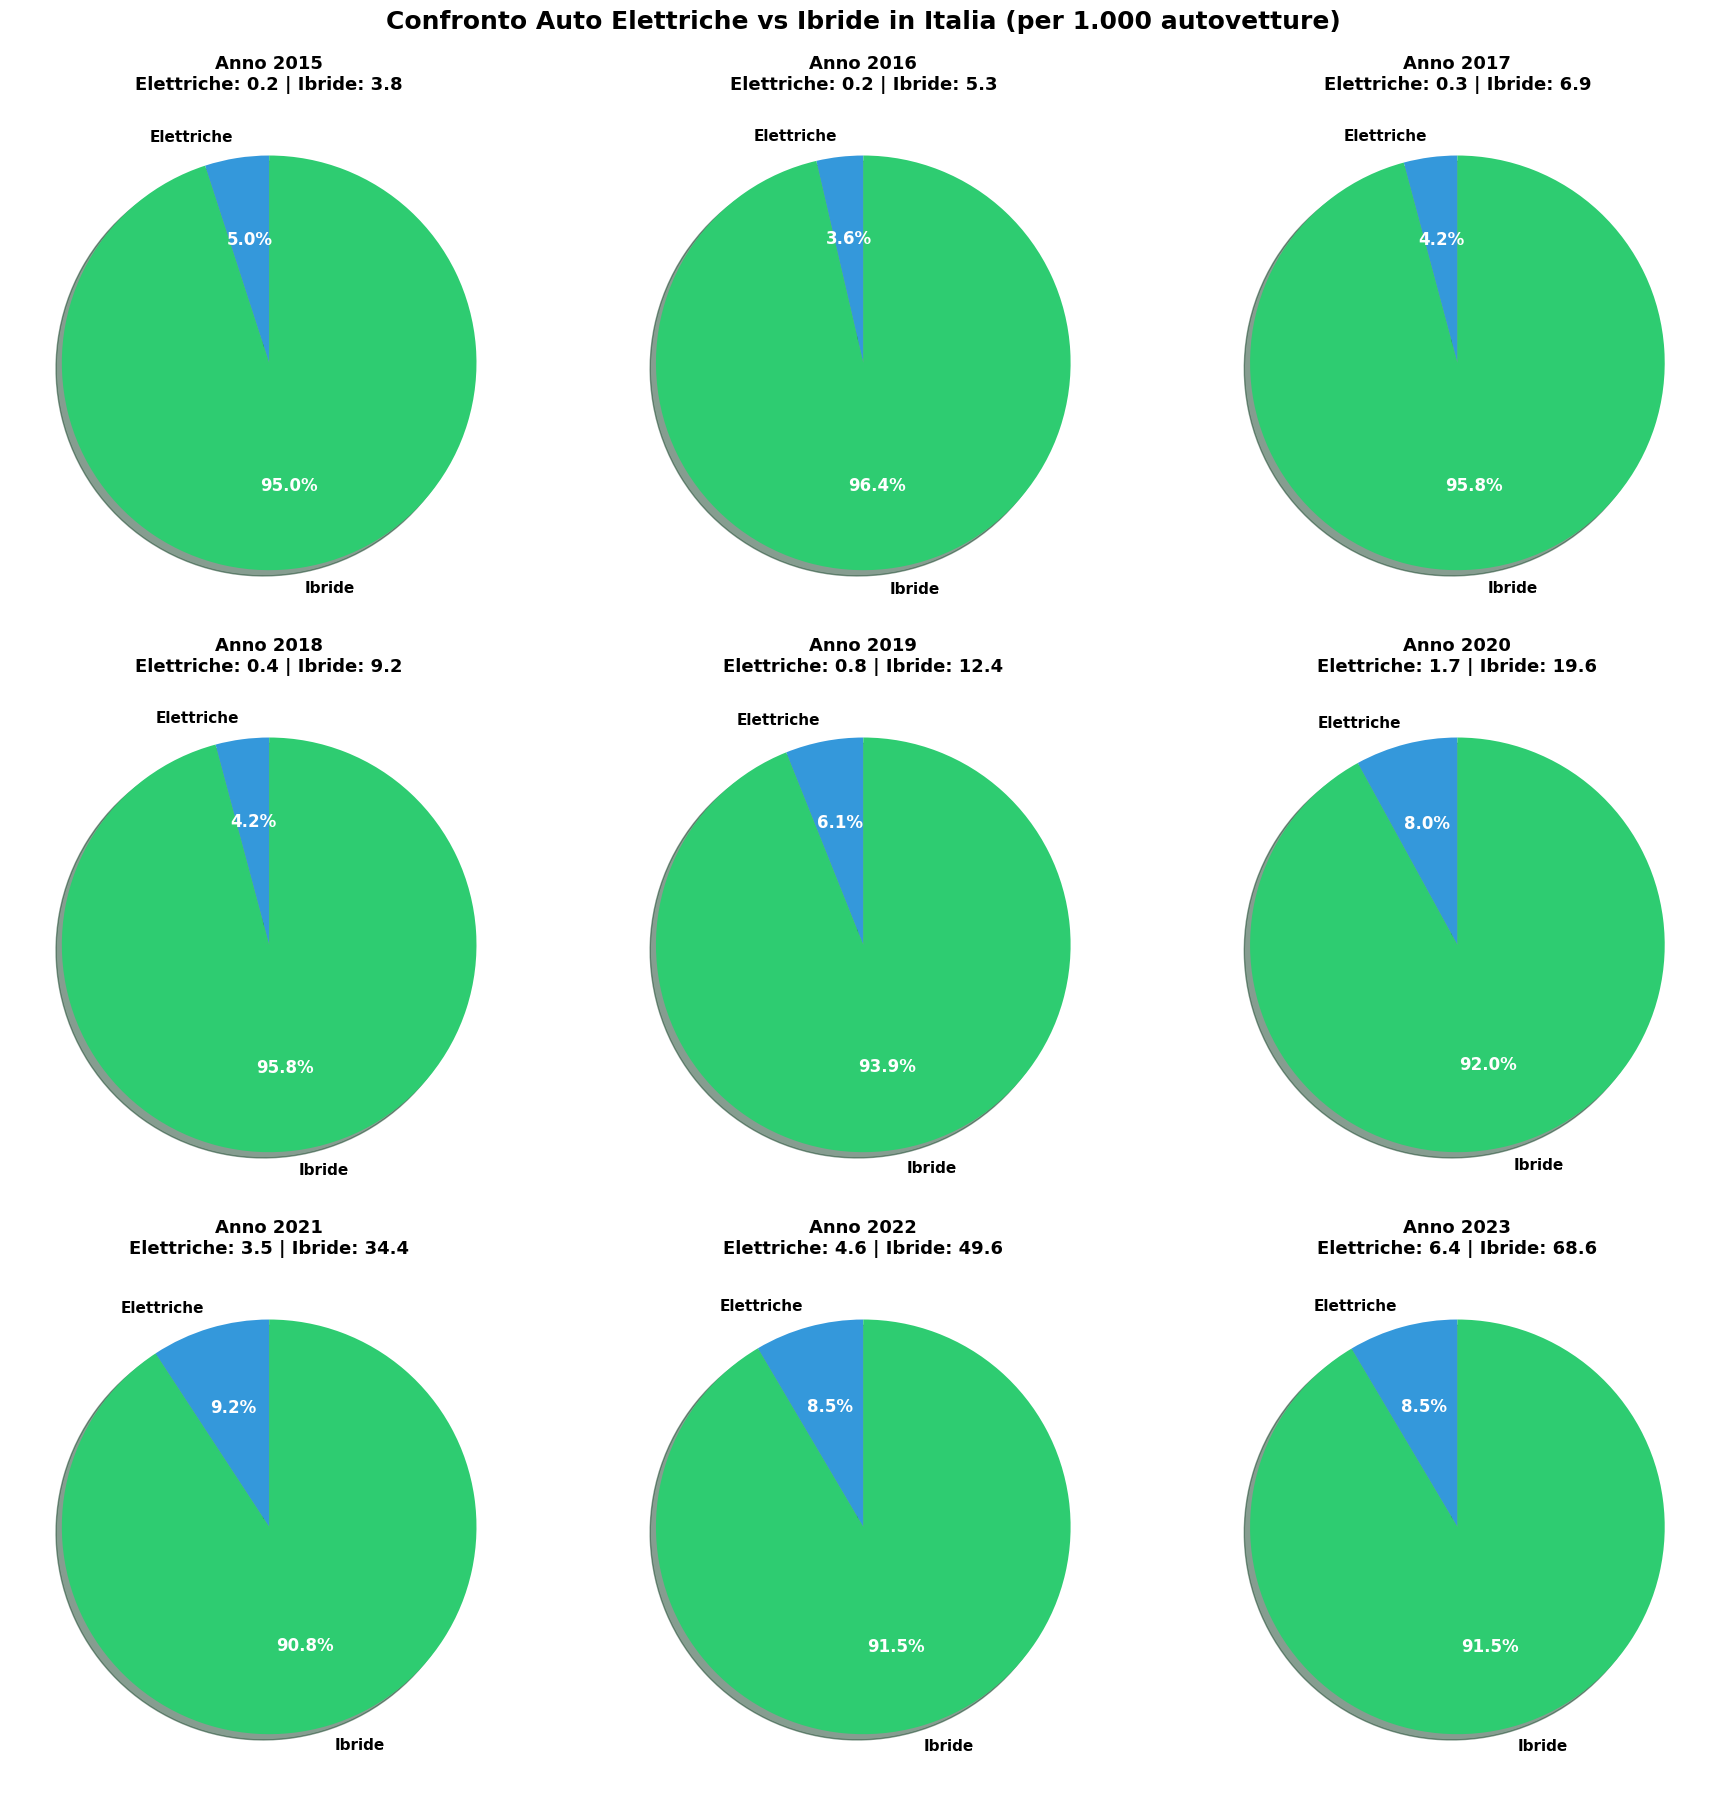

In [9]:
# Grafici a torta anno per anno
anni = sorted(df_merged['Anno'].unique())
n_anni = len(anni)
n_cols = 3
n_rows = int(np.ceil(n_anni / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
fig.suptitle('Confronto Auto Elettriche vs Ibride in Italia (per 1.000 autovetture)', 
             fontsize=18, fontweight='bold', y=0.995)

axes = axes.flatten() if n_anni > 1 else [axes]
colori = ['#3498db', '#2ecc71']

for idx, anno in enumerate(anni):
    dati_anno = df_merged[df_merged['Anno'] == anno].iloc[0]
    valori = [dati_anno['Elettriche'], dati_anno['Ibride']]
    etichette = ['Elettriche', 'Ibride']
    
    wedges, texts, autotexts = axes[idx].pie(
        valori, 
        labels=etichette,
        autopct='%1.1f%%',
        startangle=90,
        colors=colori,
        shadow=True,
        textprops={'fontsize': 11, 'fontweight': 'bold'}
    )
    
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontsize(12)
        autotext.set_fontweight('bold')
    
    axes[idx].set_title(
        f'Anno {anno}\nElettriche: {valori[0]:.1f} | Ibride: {valori[1]:.1f}',
        fontsize=13,
        fontweight='bold',
        pad=10
    )

for idx in range(n_anni, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()